In [18]:
import pandas as pd

#read the file with names classified with X and Y
df = pd.read_csv(
    "450_mb_ISCand Mwg.dat",
    delim_whitespace=True,
    header=None,
    names=["X", "Y"]
)

print(df.head())

     X         Y
0  4.5  4.636176
1  4.6  4.525882
2  4.6  4.636176
3  4.6  4.525882
4  4.7  4.525882


C:\Users\matias.DESKTOP-VU2DMIJ.000\AppData\Local\Temp\ipykernel_9592\2023769894.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [19]:
import numpy as np

#Select X columns
X = df["X"].values
#Select Y columns
Y = df["Y"].values

In [20]:
X_prom = X.mean()
Y_prom = Y.mean()

In [21]:
X_prom

np.float64(5.293555555555557)

In [22]:
Y_prom

np.float64(5.084950980433333)

In [23]:
X_lessProm = X - X_prom
Y_lessProm = Y - Y_prom

In [24]:
Sxx = float((X_lessProm**2).sum()/(X.size - 1))
Sxx

0.13904523632764165

In [25]:
Syy = float((Y_lessProm**2).sum()/(Y.size - 1))
Syy

0.2625553541105754

In [26]:
Sxy = float((X_lessProm.T*Y_lessProm).sum()/(Y.size - 1))
Sxy

0.16529373551126206

In [27]:
n_guata = 1 #lambda

In [28]:
Beta = float((Syy - n_guata*Sxx + ((Syy - n_guata*Sxx)**2 + 4*n_guata*Sxy**2)**(1/2))/(2*Sxy))
Beta

1.4411204751311666

In [29]:
Beta0 = float(Y_prom - (Beta*X_prom))
Beta0

-2.5437003169221173

In [30]:
#print the values B1, B0 and R2
print("Pendiente (β₁):", Beta)
print("Intercepto (β₀):", Beta0)

Pendiente (β₁): 1.4411204751311666
Intercepto (β₀): -2.5437003169221173


In [31]:
Xt = (((Beta * (Y - Beta0)) + 0.2 * X)/(0.2 + Beta**2))
Xt

array([4.93979622, 4.87876961, 4.94858037, 4.87876961, 4.88755376,
       4.95736452, 4.95736452, 4.95736452, 4.81774299, 4.81774299,
       4.88755376, 4.88755376, 4.81774299, 4.68690562, 4.96614867,
       5.03595943, 4.96614867, 4.96614867, 5.03595943, 4.96614867,
       4.89633791, 4.96614867, 4.96614867, 4.96614867, 4.96614867,
       4.82652714, 4.89633791, 5.03595943, 4.96614867, 4.96614867,
       4.89633791, 5.03595943, 4.96614867, 4.82652714, 4.96614867,
       4.82652714, 4.82652714, 4.96614867, 4.89633791, 4.89633791,
       4.82652714, 4.96614867, 5.04474358, 5.25417586, 5.04474358,
       5.11455434, 5.04474358, 4.97493282, 5.04474358, 4.90512206,
       5.11455434, 4.83531129, 4.97493282, 5.1843651 , 5.1843651 ,
       5.11455434, 5.11455434, 4.97493282, 4.97493282, 4.97493282,
       4.90512206, 4.97493282, 4.83531129, 5.04474358, 4.90512206,
       5.11455434, 4.83531129, 4.90512206, 4.90512206, 4.90512206,
       4.97493282, 4.97493282, 4.90512206, 4.97493282, 5.11455

In [32]:
Yt = (Beta * Xt) - Beta0
Yt

array([ 9.66254179,  9.57459509,  9.67520081,  9.57459509,  9.58725411,
        9.68785982,  9.68785982,  9.68785982,  9.48664839,  9.48664839,
        9.58725411,  9.58725411,  9.48664839,  9.29809597,  9.70051884,
        9.80112456,  9.70051884,  9.70051884,  9.80112456,  9.70051884,
        9.59991313,  9.70051884,  9.70051884,  9.70051884,  9.70051884,
        9.49930741,  9.59991313,  9.80112456,  9.70051884,  9.70051884,
        9.59991313,  9.80112456,  9.70051884,  9.49930741,  9.70051884,
        9.49930741,  9.49930741,  9.70051884,  9.59991313,  9.59991313,
        9.49930741,  9.70051884,  9.81378358, 10.11560073,  9.81378358,
        9.9143893 ,  9.81378358,  9.71317786,  9.81378358,  9.61257214,
        9.9143893 ,  9.51196643,  9.71317786, 10.01499501, 10.01499501,
        9.9143893 ,  9.9143893 ,  9.71317786,  9.71317786,  9.71317786,
        9.61257214,  9.71317786,  9.51196643,  9.81378358,  9.61257214,
        9.9143893 ,  9.51196643,  9.61257214,  9.61257214,  9.61

In [33]:
Xt2 = (X + Beta*(Y - Beta0)) / (1 + Beta**2)
Yt2 = Beta*Xt2 + Beta0

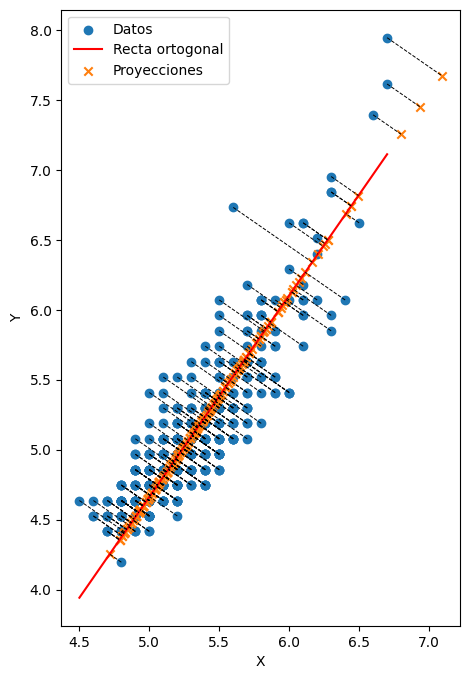

In [34]:
import matplotlib.pyplot as plt

# ===== GRAFICAR =====

fig, ax = plt.subplots(figsize=(8,8))

# Datos
ax.scatter(X, Y, label="Datos")

# Recta
x_line = np.linspace(min(X), max(X), 100)
y_line = Beta*x_line + Beta0

ax.plot(x_line, y_line,
        color="red",
        label="Recta ortogonal")

# Proyecciones
ax.scatter(Xt2, Yt2,
           marker="x",
           label="Proyecciones")

# Distancias perpendiculares
for i in range(len(X)):
    ax.plot(
        [X[i], Xt2[i]],
        [Y[i], Yt2[i]],
        "k--",
        linewidth=0.7
    )

# ESTO ES CLAVE
ax.set_aspect('equal', adjustable='box')

plt.xlabel("X")
plt.ylabel("Y")

plt.legend()
plt.show()